2D Guillotine Cutting with Defects - v5 (Maximum C-compatibility)

Changes from v4:
1. Boolean masks with numpy arrays instead of sets (your optimization)
2. cuts_defected returns (buffer, count) instead of sliced list
3. Inlined max/min as comparisons
4. All hot-path data structures are numpy arrays

In [1]:
import numpy as np
import cProfile
import pstats
import io
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
# ==============================
# Decision type constants
# ==============================

DECISION_EMPTY = 0
DECISION_FILL = 1
DECISION_CUT_X = 2
DECISION_CUT_Y = 3
DECISION_DEFECT = 4
DECISION_PURE = 5

NOT_COMPUTED = -1

In [3]:
# ==============================
# 1. Normal Pattern Computation
# ==============================

def compute_normal_patterns(item_sizes, max_L):
    """
    Returns dict mapping L -> list of valid cut positions.
    """
    sizes = sorted(set(int(s) for s in item_sizes if s > 0))
    
    reachable = [False] * (max_L + 1)
    reachable[0] = True
    
    for size in sizes:
        for z in range(size, max_L + 1):
            if reachable[z - size]:
                reachable[z] = True
    
    patterns = {}
    for L in range(max_L + 1):
        patterns[L] = [z for z in range(1, L) if reachable[z]]
    
    return patterns

In [4]:
# ==============================
# 2. Geometry
# ==============================

class SheetGeometry:
    """Handles defects with O(1) purity queries."""
    
    def __init__(self, sheet_sz, defect_sizes, defect_positions):
        self.W0, self.H0 = sheet_sz
        
        # Store defects as list of tuples: (x, y, w, h, x_end, y_end)
        # Tuple unpacking is fast in Python
        self.defects = []
        n_def = len(defect_sizes[0]) if len(defect_sizes) > 0 and len(defect_sizes[0]) > 0 else 0
        
        for i in range(n_def):
            dx = int(defect_positions[0][i])
            dy = int(defect_positions[1][i])
            dw = int(defect_sizes[0][i])
            dh = int(defect_sizes[1][i])
            self.defects.append((dx, dy, dw, dh, dx + dw, dy + dh))
        
        self.n_def = n_def
        self._build_prefix()
    
    def _build_prefix(self):
        W0, H0 = self.W0, self.H0
        
        if self.n_def == 0:
            self.prefix = np.zeros((W0 + 1, H0 + 1), dtype=np.int32)
            return
        
        grid = np.zeros((W0, H0), dtype=np.int32)
        
        for (dx, dy, dw, dh, dx_end, dy_end) in self.defects:
            x1 = dx if dx > 0 else 0
            y1 = dy if dy > 0 else 0
            x2 = dx_end if dx_end < W0 else W0
            y2 = dy_end if dy_end < H0 else H0
            if x1 < x2 and y1 < y2:
                grid[x1:x2, y1:y2] = 1
        
        self.prefix = np.zeros((W0 + 1, H0 + 1), dtype=np.int32)
        self.prefix[1:, 1:] = np.cumsum(np.cumsum(grid, axis=0), axis=1)
    
    def is_pure(self, x, y, w, h):
        if w <= 0 or h <= 0 or self.n_def == 0:
            return True
        
        # Inline max/min
        x0 = x if x > 0 else 0
        y0 = y if y > 0 else 0
        x1 = x + w if x + w < self.W0 else self.W0
        y1 = y + h if y + h < self.H0 else self.H0
        
        if x0 >= x1 or y0 >= y1:
            return True
        
        P = self.prefix
        return (P[x1, y1] - P[x0, y1] - P[x1, y0] + P[x0, y0]) == 0


In [5]:
# ==============================
# 3. Cut Pattern Generator
# ==============================

class CutPatternGenerator:
    """Generates candidate cut positions using boolean masks."""
    
    def __init__(self, item_sizes, geometry):
        self.geom = geometry
        self.W0, self.H0 = geometry.W0, geometry.H0
        
        self.np_x = compute_normal_patterns(item_sizes[0], self.W0)
        self.np_y = compute_normal_patterns(item_sizes[1], self.H0)
        
        # Scratch buffers (Python lists - faster than numpy for element access)
        self._x_mask = [False] * (self.W0 + 1)
        self._y_mask = [False] * (self.H0 + 1)
        self._x_buf = [0] * (self.W0 + 1)
        self._y_buf = [0] * (self.H0 + 1)
    
    def cuts_pure_x(self, w):
        return self.np_x.get(w, [])
    
    def cuts_pure_y(self, h):
        return self.np_y.get(h, [])
    
    def cuts_defected(self, x, y, w, h):
        if w <= 1 and h <= 1:
            return [], []

        x_mask = self._x_mask
        y_mask = self._y_mask
        x_buf  = self._x_buf
        y_buf  = self._y_buf

        # Hoisted branch conditions
        do_x = w > 1
        do_y = h > 1

        # Clear masks
        for i in range(1, w):
            x_mask[i] = False
        for i in range(1, h):
            y_mask[i] = False

        # Normal patterns
        for z in self.np_x.get(w, []):
            x_mask[z] = True
        for z in self.np_y.get(h, []):
            y_mask[z] = True

        x_end = x + w
        y_end = y + h

        for (dx, dy, dw, dh, dx_end, dy_end) in self.geom.defects:
            if x >= dx_end or y >= dy_end or dx >= x_end or dy >= y_end:
                continue

            # X direction
            if do_x:
                left  = dx - x
                right = dx_end - x

                if 0 < left < w:
                    x_mask[left] = True

                if 0 < right < w:
                    x_mask[right] = True
                    rem = w - right
                    for z in self.np_x.get(rem, []):
                        zz = right + z
                        if zz < w:
                            x_mask[zz] = True

            # Y direction
            if do_y:
                bot = dy - y
                top = dy_end - y

                if 0 < bot < h:
                    y_mask[bot] = True

                if 0 < top < h:
                    y_mask[top] = True
                    rem = h - top
                    for z in self.np_y.get(rem, []):
                        zz = top + z
                        if zz < h:
                            y_mask[zz] = True

        # Compact
        nx = 0
        for i in range(1, w):
            if x_mask[i]:
                x_buf[nx] = i
                nx += 1

        ny = 0
        for i in range(1, h):
            if y_mask[i]:
                y_buf[ny] = i
                ny += 1

        return x_buf[:nx], y_buf[:ny]


In [6]:
# ==============================
# 4. DP Solver
# ==============================

class GuillotineDP:
    """DP solver with numpy array memoization."""
    
    def __init__(self, item_sizes, geometry, patterns):
        self.item_w = np.array(item_sizes[0], dtype=np.int32)
        self.item_h = np.array(item_sizes[1], dtype=np.int32)
        self.item_area = self.item_w * self.item_h
        self.n_items = len(self.item_w)
        
        self.geom = geometry
        self.patterns = patterns
        self.W0 = geometry.W0
        self.H0 = geometry.H0
        
        # F memoization
        self.values_F = np.full((self.W0 + 1, self.H0 + 1), NOT_COMPUTED, dtype=np.int32)
        self.decisions_F_type = np.zeros((self.W0 + 1, self.H0 + 1), dtype=np.int8)
        self.decisions_F_param = np.zeros((self.W0 + 1, self.H0 + 1), dtype=np.int32)
        
        # F_d memoization
        self.values_Fd = np.full((self.W0, self.H0, self.W0 + 1, self.H0 + 1), NOT_COMPUTED, dtype=np.int32)
        self.decisions_Fd_type = np.zeros((self.W0, self.H0, self.W0 + 1, self.H0 + 1), dtype=np.int8)
        self.decisions_Fd_param = np.zeros((self.W0, self.H0, self.W0 + 1, self.H0 + 1), dtype=np.int32)
    
    def g(self, w, h):
        """Best single-item fill. Returns (value, index)."""
        if w <= 0 or h <= 0:
            return 0, -1
        
        best_val = 0
        best_idx = -1
        
        item_w = self.item_w
        item_h = self.item_h
        item_area = self.item_area
        
        for i in range(self.n_items):
            nx = w // item_w[i]
            ny = h // item_h[i]
            val = item_area[i] * nx * ny
            if val > best_val:
                best_val = val
                best_idx = i
        
        return int(best_val), best_idx
    
    def F(self, w, h):
        """Pure sheet DP."""
        if w <= 0 or h <= 0:
            return 0
        
        if self.values_F[w, h] != NOT_COMPUTED:
            return self.values_F[w, h]
        
        g_val, g_idx = self.g(w, h)
        best_val = g_val
        best_type = DECISION_FILL if g_idx >= 0 else DECISION_EMPTY
        best_param = g_idx if g_idx >= 0 else 0
        
        # Vertical cuts (symmetry)
        half_w = w >> 1  # Bit shift instead of //2
        for z in self.patterns.cuts_pure_x(w):
            if z > half_w:
                break
            total = self.F(z, h) + self.F(w - z, h)
            if total > best_val:
                best_val = total
                best_type = DECISION_CUT_X
                best_param = z
        
        # Horizontal cuts (symmetry)
        half_h = h >> 1
        for z in self.patterns.cuts_pure_y(h):
            if z > half_h:
                break
            total = self.F(w, z) + self.F(w, h - z)
            if total > best_val:
                best_val = total
                best_type = DECISION_CUT_Y
                best_param = z
        
        self.values_F[w, h] = best_val
        self.decisions_F_type[w, h] = best_type
        self.decisions_F_param[w, h] = best_param
        
        return best_val
    
    def F_d(self, x, y, w, h):
        """Defected sheet DP."""
        if w <= 0 or h <= 0:
            return 0
        
        if self.values_Fd[x, y, w, h] != NOT_COMPUTED:
            return self.values_Fd[x, y, w, h]
        
        if self.geom.is_pure(x, y, w, h):
            val = self.F(w, h)
            self.values_Fd[x, y, w, h] = val
            self.decisions_Fd_type[x, y, w, h] = DECISION_PURE
            self.decisions_Fd_param[x, y, w, h] = 0
            return val
        
        best_val = 0
        best_type = DECISION_DEFECT
        best_param = 0
        
        # Get cuts (returns sliced lists)
        X_cuts, Y_cuts = self.patterns.cuts_defected(x, y, w, h)
        
        # Vertical cuts
        for z in X_cuts:
            total = self.F_d(x, y, z, h) + self.F_d(x + z, y, w - z, h)
            if total > best_val:
                best_val = total
                best_type = DECISION_CUT_X
                best_param = z
        
        # Horizontal cuts
        for z in Y_cuts:
            total = self.F_d(x, y, w, z) + self.F_d(x, y + z, w, h - z)
            if total > best_val:
                best_val = total
                best_type = DECISION_CUT_Y
                best_param = z
        
        self.values_Fd[x, y, w, h] = best_val
        self.decisions_Fd_type[x, y, w, h] = best_type
        self.decisions_Fd_param[x, y, w, h] = best_param
        
        return best_val
    
    def reconstruct_F(self, w, h):
        if w <= 0 or h <= 0:
            return 'empty'
        
        dec_type = self.decisions_F_type[w, h]
        dec_param = self.decisions_F_param[w, h]
        
        if dec_type == DECISION_EMPTY:
            return 'empty'
        if dec_type == DECISION_FILL:
            return f'g_{dec_param}'
        if dec_type == DECISION_CUT_X:
            z = int(dec_param)
            return ('X', z, self.reconstruct_F(z, h), self.reconstruct_F(w - z, h))
        if dec_type == DECISION_CUT_Y:
            z = int(dec_param)
            return ('Y', z, self.reconstruct_F(w, z), self.reconstruct_F(w, h - z))
        return 'empty'
    
    def reconstruct_Fd(self, x, y, w, h):
        if w <= 0 or h <= 0:
            return 'empty'
        
        dec_type = self.decisions_Fd_type[x, y, w, h]
        dec_param = self.decisions_Fd_param[x, y, w, h]
        
        if dec_type == DECISION_PURE:
            return self.reconstruct_F(w, h)
        if dec_type == DECISION_EMPTY:
            return 'empty'
        if dec_type == DECISION_FILL:
            return f'g_{dec_param}'
        if dec_type == DECISION_DEFECT:
            return 'defect'
        if dec_type == DECISION_CUT_X:
            z = int(dec_param)
            return ('X', z, self.reconstruct_Fd(x, y, z, h), self.reconstruct_Fd(x + z, y, w - z, h))
        if dec_type == DECISION_CUT_Y:
            z = int(dec_param)
            return ('Y', z, self.reconstruct_Fd(x, y, w, z), self.reconstruct_Fd(x, y + z, w, h - z))
        return 'empty'
    
    def solve(self):
        value = self.F_d(0, 0, self.W0, self.H0)
        sequence = self.reconstruct_Fd(0, 0, self.W0, self.H0)
        return value, sequence

In [7]:
# ==============================
# 5. Plotting (unchanged)
# ==============================

class CuttingPlots:
    def __init__(self, item_sizes, defect_sizes, def_pos, sheet_sz):
        self.item_sizes = item_sizes
        self.defect_sizes = defect_sizes
        self.def_pos = def_pos
        self.sheet_sz = sheet_sz
        self.xticks = []
        self.yticks = []

    def fill_same_item(self, w, h, item_w, item_h, color, pos=(0, 0)):
        rows = h // item_h
        cols = w // item_w
        ox, oy = pos
        ax = plt.gca()
        for i in range(rows):
            for j in range(cols):
                rect = patches.Rectangle(
                    (ox + j * item_w, oy + i * item_h),
                    item_w, item_h,
                    linewidth=0.8, edgecolor='k', facecolor=color
                )
                ax.add_patch(rect)

    def draw_cuts(self, seq, w, h, colors, offset=(0, 0)):
        ox, oy = offset
        if isinstance(seq, str):
            if seq.startswith("g_"):
                i = int(seq.split("_")[1])
                self.fill_same_item(w, h, self.item_sizes[0][i], self.item_sizes[1][i], colors[i], offset)
            return
        direction, z, left, right = seq
        if direction == 'X':
            plt.plot([ox + z, ox + z], [oy, oy + h], 'k', linewidth=1.5)
            self.xticks.append(ox + z)
            self.draw_cuts(left, z, h, colors, (ox, oy))
            self.draw_cuts(right, w - z, h, colors, (ox + z, oy))
        else:
            plt.plot([ox, ox + w], [oy + z, oy + z], 'k', linewidth=1.5)
            self.yticks.append(oy + z)
            self.draw_cuts(left, w, z, colors, (ox, oy))
            self.draw_cuts(right, w, h - z, colors, (ox, oy + z))

    def plot_cuts(self, seq, colors):
        W0, H0 = self.sheet_sz
        fig, ax = plt.subplots(figsize=(8, 8 * H0 / W0))
        ax.set_xlim(-1, W0 + 1)
        ax.set_ylim(-1, H0 + 1)
        ax.set_aspect('equal')
        ax.add_patch(plt.Rectangle((0, 0), W0, H0, linewidth=2, edgecolor='k', facecolor='lightgrey', hatch='//'))
        for i in range(len(self.defect_sizes[0])):
            ax.add_patch(plt.Rectangle(
                (self.def_pos[0][i], self.def_pos[1][i]),
                self.defect_sizes[0][i], self.defect_sizes[1][i],
                linewidth=1, edgecolor='k', facecolor='k'
            ))
        self.xticks.clear()
        self.yticks.clear()
        self.draw_cuts(seq, W0, H0, colors, (0, 0))
        plt.xticks([0] + sorted(set(self.xticks)) + [W0])
        plt.yticks([0] + sorted(set(self.yticks)) + [H0])
        plt.show()

In [8]:
# ==============================
# 6. Main solver class
# ==============================

class GuillotineCuts2D:
    def __init__(self, item_sizes, defect_sizes, def_pos, sheet_sz):
        self.item_sizes = item_sizes
        self.defect_sizes = defect_sizes
        self.def_pos = def_pos
        self.sheet_sz = sheet_sz
        self.geometry = SheetGeometry(sheet_sz, defect_sizes, def_pos)
        self.patterns = CutPatternGenerator(item_sizes, self.geometry)
        self.solver = GuillotineDP(item_sizes, self.geometry, self.patterns)
        self.plots = CuttingPlots(item_sizes, defect_sizes, def_pos, sheet_sz)

    def colormap(self):
        cmap = plt.get_cmap('tab10')
        return {i: cmap(i % 10) for i in range(len(self.item_sizes[0]))}

    def plot_items_catalog(self, colors):
        w, h = self.item_sizes
        max_dim = max(max(w), max(h))
        factor = 5 / max_dim
        fig, ax = plt.subplots(figsize=(6, 2))
        x = 0
        for i in range(len(w)):
            width = w[i] * factor
            height = h[i] * factor
            ax.add_patch(patches.Rectangle((x, 0), width, height, linewidth=1, edgecolor='k', facecolor=colors[i]))
            plt.text(x + width / 2, height / 2, f"{i}", ha='center', va='center')
            plt.text(x + width / 2, -0.5, f"{w[i]} x {h[i]}", ha='center')
            x += width + 0.5
        ax.set_xlim(-1, x + 1)
        ax.set_ylim(-1, max(h) * factor + 1)
        ax.set_aspect('equal')
        plt.axis('off')
        plt.show()

    def plot_defects(self):
        W, H = self.sheet_sz
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.add_patch(patches.Rectangle((0, 0), W, H, linewidth=2, edgecolor='black', facecolor='lightgrey', hatch='//'))
        for i in range(len(self.defect_sizes[0])):
            ax.add_patch(patches.Rectangle(
                (self.def_pos[0][i], self.def_pos[1][i]),
                self.defect_sizes[0][i], self.defect_sizes[1][i],
                linewidth=1, facecolor='k'
            ))
        ax.set_xlim(-1, W + 1)
        ax.set_ylim(-1, H + 1)
        ax.set_aspect('equal')
        plt.axis('off')
        plt.show()

    def Solve(self, profile=False):
        W0, H0 = self.sheet_sz
        colors = self.colormap()
        print(f"Solving 2D guillotine cut with defects (sheet {W0} x {H0})")
        print("Item catalog:")
        self.plot_items_catalog(colors)
        print("Defects:")
        self.plot_defects()

        def run():
            print("Computing optimal cuts...")
            val, seq = self.solver.solve()
            print("Plotting result...")
            self.plots.plot_cuts(seq, colors)
            print(f"\nResults:")
            print(f"  Total area = {W0 * H0}")
            print(f"  Cut area   = {val}")
            print(f"  Waste      = {W0 * H0 - val} ({100 * (W0 * H0 - val) / (W0 * H0):.1f}%)")
            print(f"\nCut sequence:\n{seq}")
            return val, seq

        if not profile:
            return run()
        else:
            pr = cProfile.Profile()
            pr.enable()
            val, seq = run()
            pr.disable()
            s = io.StringIO()
            pstats.Stats(pr, stream=s).sort_stats("cumtime").print_stats(50)
            print("\n--- cProfile output ---")
            print(s.getvalue())
            return val, seq

Solving 2D guillotine cut with defects (sheet 60 x 60)
Item catalog:


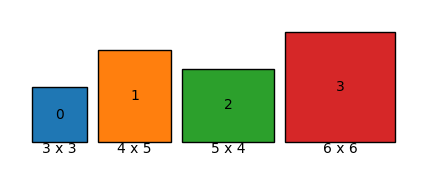

Defects:


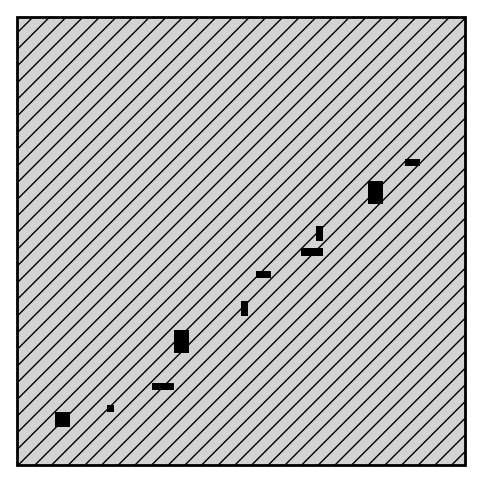

Computing optimal cuts...
Plotting result...


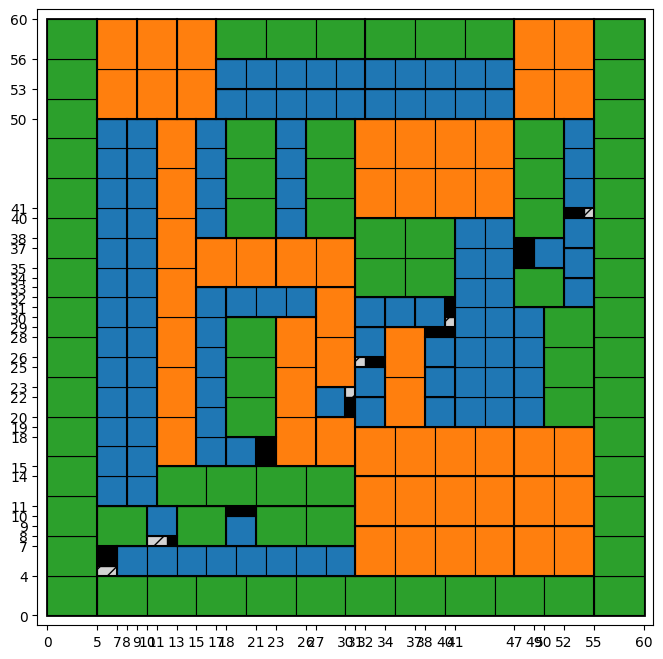


Results:
  Total area = 3600
  Cut area   = 3561
  Waste      = 39 (1.1%)

Cut sequence:
('X', 5, 'g_2', ('X', 50, ('Y', 4, 'g_2', ('X', 42, ('Y', 46, ('X', 26, ('Y', 3, ('X', 2, 'defect', 'g_0'), ('Y', 4, ('X', 5, 'g_2', ('X', 3, ('Y', 1, 'defect', 'g_0'), ('X', 5, 'g_2', ('X', 3, ('Y', 3, 'g_0', 'defect'), 'g_2')))), ('X', 3, 'g_0', ('X', 3, 'g_0', ('Y', 4, 'g_2', ('X', 4, 'g_1', ('Y', 18, ('X', 3, 'g_0', ('X', 9, ('Y', 15, ('X', 5, ('Y', 3, ('X', 3, 'g_0', 'defect'), 'g_2'), 'g_1'), 'g_0'), ('Y', 5, 'g_1', ('Y', 3, ('X', 3, 'g_0', 'defect'), 'g_1')))), ('X', 8, ('Y', 5, 'g_1', ('X', 3, 'g_0', 'g_2')), ('Y', 5, 'g_1', ('X', 3, 'g_0', 'g_2')))))))))), ('Y', 5, 'g_1', ('Y', 5, 'g_1', ('Y', 5, 'g_1', ('Y', 21, ('X', 10, ('Y', 10, ('X', 3, ('Y', 3, 'g_0', ('Y', 3, 'g_0', ('Y', 1, 'defect', 'g_0'))), ('X', 4, 'g_1', ('Y', 3, 'g_0', ('Y', 3, 'g_0', ('Y', 3, 'g_0', 'defect'))))), ('Y', 3, ('X', 3, 'g_0', ('X', 3, 'g_0', ('X', 3, 'g_0', 'defect'))), 'g_2')), 'g_0'), 'g_1'))))), ('X', 4, 'g_

In [9]:
W0, H0 = 60, 60
item_sizes = [[3, 4, 5, 6], [3, 5, 4, 6]]
defect_sizes = [[2, 1, 3, 2, 1, 2, 3, 1, 2, 2], [2, 1, 1, 3, 2, 1, 1, 2, 3, 1]]
defect_positions = [[5, 12, 18, 21, 30, 32, 38, 40, 47, 52], [5, 7, 10, 15, 20, 25, 28, 30, 35, 40]]

problem = GuillotineCuts2D(item_sizes, defect_sizes, defect_positions, (W0, H0))
val, seq = problem.Solve(profile=True)